# Unidad 1 · Entorno de trabajo y datos en Python

**Qué vas a aprender**
- Comprobar el entorno: qué versión de Python tienes y qué librerías están instaladas.
- Descargar precios reales de Binance, entender lo que devuelve y pasarlo a un *DataFrame*.
- Revisar la calidad de los datos antes de usarlos: huecos, duplicados, velas imposibles.
- Construir y guardar la base histórica con la que trabajan todos los cuadernos siguientes.

**Qué tiene que ver con la app.** El *piloto de riesgo* empieza exactamente aquí: antes de recomendar
nada, descarga los cierres diarios de cada moneda desde 2020 y los guarda para no volver a pedirlos.
Al final de este cuaderno habrás construido esa misma base, y sabrás por qué cada paso está ahí.

**Cómo se usa.** Ejecuta las celdas en orden con **Shift + Enter**. Lee el texto antes del código y
el resultado después: los números que salen se comentan en el texto. Si una celda falla, lee el
mensaje de error de abajo arriba: la última línea suele decir qué pasó.

## 1. El entorno

Un *entorno* es un Python con sus librerías. En **Google Colab** ya viene montado: pandas, NumPy,
matplotlib, scikit-learn y statsmodels están instalados. En tu equipo, la guía de instalación del
curso crea uno con `python -m venv`. Si falta una librería, se instala con `pip`:

```
%pip install arch          # en Colab o Jupyter, dentro de una celda
python -m pip install arch # en la terminal de tu equipo
```

Lo primero es saber con qué trabajas. Las versiones importan: un cuaderno que funciona con pandas 2
puede fallar con pandas 1.

In [1]:
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

print("Python    ", sys.version.split()[0])
for libreria in (pd, np, matplotlib, requests):
    print(f"{libreria.__name__:10}", libreria.__version__)

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

Python     3.11.8
pandas     2.3.3
numpy      2.2.6
matplotlib 3.11.1
requests   2.34.2


## 2. Una petición a Binance

Binance publica gratis sus datos de mercado. No hace falta cuenta ni clave porque son públicos:
cualquiera puede preguntar el precio. Usamos el dominio `data-api.binance.vision`, porque
`api.binance.com` rechaza las conexiones desde Estados Unidos, que es donde están los servidores
de Colab. El piloto usa el mismo dominio.

Cada fila que devuelve es una **vela**: lo que pasó con el precio durante un intervalo (aquí, un día).
Pidamos solo tres para ver la forma de la respuesta.

In [2]:
API = "https://data-api.binance.vision/api/v3/klines"
respuesta = requests.get(API, params={"symbol": "BTCUSDT", "interval": "1d",
                                      "startTime": 1672531200000, "limit": 3}, timeout=30)
print("Código HTTP:", respuesta.status_code)      # 200 = todo bien
crudo = respuesta.json()
crudo

Código HTTP: 200


[[1672531200000,
  '16541.77000000',
  '16628.00000000',
  '16499.01000000',
  '16616.75000000',
  '96925.41374000',
  1672617599999,
  '1604793789.67721260',
  3218355,
  '48548.78168000',
  '803841673.83505870',
  '0'],
 [1672617600000,
  '16617.17000000',
  '16799.23000000',
  '16548.70000000',
  '16672.87000000',
  '121888.57191000',
  1672703999999,
  '2034683215.26787840',
  4036118,
  '60925.25948000',
  '1017074780.69180630',
  '0'],
 [1672704000000,
  '16672.78000000',
  '16778.40000000',
  '16605.28000000',
  '16675.18000000',
  '159541.53733000',
  1672790399999,
  '2662765916.32566840',
  5097596,
  '79595.76246000',
  '1328471402.71367460',
  '0']]

La respuesta es una lista de listas, una por vela, con 12 campos sin nombre. La documentación de
Binance dice qué es cada uno:

| Posición | Campo | Ejemplo |
|---|---|---|
| 0 | hora de **apertura**, en milisegundos desde 1970 (UTC) | `1672531200000` = 01-01-2023 00:00 |
| 1 a 4 | apertura, máximo, mínimo, **cierre** | como **texto**, no como número |
| 5 | volumen, en BTC | |
| 6 | hora de **cierre** de la vela | 23:59:59.999 del mismo día |
| 7 a 11 | volumen en USDT, número de operaciones y otros | no los usaremos |

Tres trampas clásicas, que la IA comete a menudo:
1. Los precios llegan como texto (`"16616.75"`): hay que convertirlos a número.
2. Las fechas están en **milisegundos**. Si se leen como segundos o nanosegundos, sale el año 1970 o el 54 000.
3. Hay que fechar la vela con la hora de **apertura** (campo 0). Con la de cierre, cada vela parece
   del día siguiente.

El cierre del 01-01-2023 fue **16 616,75 USDT**. Lo usaremos como control.

In [3]:
filas = pd.DataFrame(crudo).iloc[:, :6]
filas.columns = ["apertura_ms", "open", "high", "low", "close", "volume"]
print(filas.dtypes)                                 # 'object' = texto
filas["fecha"] = pd.to_datetime(filas["apertura_ms"], unit="ms", utc=True)
for c in ["open", "high", "low", "close", "volume"]:
    filas[c] = filas[c].astype(float)
filas[["fecha", "open", "high", "low", "close", "volume"]]

apertura_ms     int64
open           object
high           object
low            object
close          object
volume         object
dtype: object


,fecha,open,high,low,close,volume
0,2023-01-01 00:00:00+00:00,16541.77,16628.00,16499.01,16616.75,96925.41374
1,2023-01-02 00:00:00+00:00,16617.17,16799.23,16548.70,16672.87,121888.57191
2,2023-01-03 00:00:00+00:00,16672.78,16778.40,16605.28,16675.18,159541.53733


## 3. Muchas velas: paginación

Binance devuelve como mucho 1000 velas por petición. Desde 2020 hay más de 2400 días, así que
hay que pedir por **páginas**: cada petición empieza justo después de la última vela recibida, y se
para cuando llega una página incompleta.

También hay que quitar la vela **de hoy**: todavía no ha cerrado, y su "cierre" es el precio de este
instante, que seguirá cambiando. El piloto decide solo con velas cerradas por la misma razón: si
decidiera con la vela abierta, la recomendación cambiaría cada minuto.

In [4]:
def descargar(simbolo, desde="2020-01-01"):
    """Velas diarias YA CERRADAS de SIMBOLO/USDT en Binance, 1000 por petición."""
    inicio = int(pd.Timestamp(desde, tz="UTC").timestamp() * 1000)
    filas = []
    while True:
        r = requests.get(API, params={"symbol": f"{simbolo}USDT", "interval": "1d",
                                      "startTime": inicio, "limit": 1000}, timeout=30)
        r.raise_for_status()                          # si Binance responde con error, que se vea
        lote = r.json()
        filas += lote
        if len(lote) < 1000:                          # página incompleta: no hay más
            break
        inicio = lote[-1][0] + 1                      # la siguiente, tras la última vela
    crudo = pd.DataFrame([f[:7] for f in filas],
                         columns=["apertura_ms", "open", "high", "low", "close", "volume", "cierre_ms"])
    ahora_ms = pd.Timestamp.now(tz="UTC").timestamp() * 1000
    crudo = crudo[crudo["cierre_ms"] < ahora_ms]      # fuera la vela que no ha cerrado
    df = pd.DataFrame({"fecha": pd.to_datetime(crudo["apertura_ms"], unit="ms", utc=True)})
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = crudo[c].astype(float).to_numpy()
    return df.drop_duplicates("fecha").reset_index(drop=True)


btc = descargar("BTC")
print(len(btc), "velas, del", btc["fecha"].min().date(), "al", btc["fecha"].max().date())
btc.tail()

2466 velas, del 2020-01-01 al 2026-10-01


,fecha,open,high,low,close,volume
2461,2026-09-27 00:00:00+00:00,84433.11,85159.03,84132.00,84472.00,9615.12963
2462,2026-09-28 00:00:00+00:00,84472.01,84999.00,82563.00,83500.01,20960.72462
2463,2026-09-29 00:00:00+00:00,83500.01,84563.99,82775.94,83663.66,13461.55331
2464,2026-09-30 00:00:00+00:00,83663.66,85649.95,82956.11,83623.60,18522.82001
2465,2026-10-01 00:00:00+00:00,83623.59,85273.65,83186.00,84880.05,16766.05675


## 4. ¿Los datos son buenos?

Un modelo con datos malos da resultados malos aunque el código sea perfecto. Antes de calcular
nada, cinco comprobaciones:

1. **Tipos**: las fechas son fechas y los precios, números.
2. **Orden y duplicados**: cada día aparece una vez, del más antiguo al más reciente.
3. **Huecos**: no falta ningún día. Binance tuvo algunas paradas de mantenimiento.
4. **Coherencia**: el máximo es el mayor de los cuatro precios y el mínimo el menor.
5. **Control**: el cierre de un día conocido coincide con el oficial.

In [5]:
print(btc.dtypes, "\n")
print("Ordenadas:", btc["fecha"].is_monotonic_increasing, "| Fechas repetidas:", btc["fecha"].duplicated().sum())

saltos = btc["fecha"].diff().dt.days
print("Huecos de más de un día:", int((saltos > 1).sum()))

imposibles = (btc["high"] < btc[["open", "close"]].max(axis=1)) | (btc["low"] > btc[["open", "close"]].min(axis=1))
print("Velas imposibles:", int(imposibles.sum()))
print("Valores vacíos:", int(btc.isna().sum().sum()))

control = btc.loc[btc["fecha"] == "2023-01-01", "close"].item()
print("Cierre del 01-01-2023:", control, "(debe ser 16616.75)")

fecha     datetime64[ns, UTC]
open                  float64
high                  float64
low                   float64
close                 float64
volume                float64
dtype: object 

Ordenadas: True | Fechas repetidas: 0
Huecos de más de un día: 0
Velas imposibles: 0
Valores vacíos: 0
Cierre del 01-01-2023: 16616.75 (debe ser 16616.75)


`describe()` resume cada columna. Sirve para ver de un vistazo si hay algo raro: un precio negativo,
un cero o un máximo absurdo.

In [6]:
btc.describe().round(2)

,open,high,low,close,volume
count,2466.00,2466.00,2466.00,2466.00,2466.00
mean,50038.96,51040.19,48974.09,50070.52,67711.05
std,30878.64,31324.27,30397.10,30874.52,83973.89
min,4800.01,5365.42,3782.13,4800.00,3104.12
25%,23827.51,24449.16,23345.34,23845.88,22175.38
50%,43968.68,44874.00,42861.52,43980.25,40830.38
75%,68912.59,70283.50,67530.52,68946.44,73059.36
max,124658.54,126199.63,123084.00,124658.54,760705.36


## 5. Estructurar la base: varias monedas en una tabla

La cartera de ejemplo del piloto tiene **BTC, ETH y SOL** (además de dólares digitales, USDT). Para
analizarlas juntas, se ponen sus cierres en una tabla con **una fila por día y una columna por
moneda**. La fecha pasa a ser el *índice* de la tabla, así pandas alinea las monedas por día.

SOL empezó a cotizar en Binance en agosto de 2020: sus primeros meses quedan vacíos (`NaN`).
Lo importante es no rellenarlos con un precio inventado. Más adelante, cuando hagan falta las tres
a la vez, nos quedaremos con los **días comunes**, como hace el piloto.

In [7]:
ACTIVOS = ["BTC", "ETH", "SOL"]
base = {a: descargar(a) for a in ACTIVOS}
cierres = pd.DataFrame({a: df.set_index("fecha")["close"] for a, df in base.items()})
print(cierres.notna().sum())                        # días con precio de cada moneda
print("Primer día de SOL:", cierres["SOL"].first_valid_index().date())
cierres.tail()

BTC    2466
ETH    2466
SOL    2243
dtype: int64
Primer día de SOL: 2020-08-11


,BTC,ETH,SOL
fecha,,,
2026-09-27 00:00:00+00:00,84472.00,2688.65,121.99
2026-09-28 00:00:00+00:00,83500.01,2688.71,118.89
2026-09-29 00:00:00+00:00,83663.66,2677.98,119.15
2026-09-30 00:00:00+00:00,83623.60,2686.01,118.12
2026-10-01 00:00:00+00:00,84880.05,2706.42,118.41


Un gráfico de los tres precios juntos no sirve de mucho: BTC vale decenas de miles de dólares y SOL
decenas. Para compararlos, se **normaliza** cada serie a 100 el primer día común. Así se lee qué
habría pasado con 100 dólares invertidos en cada moneda.

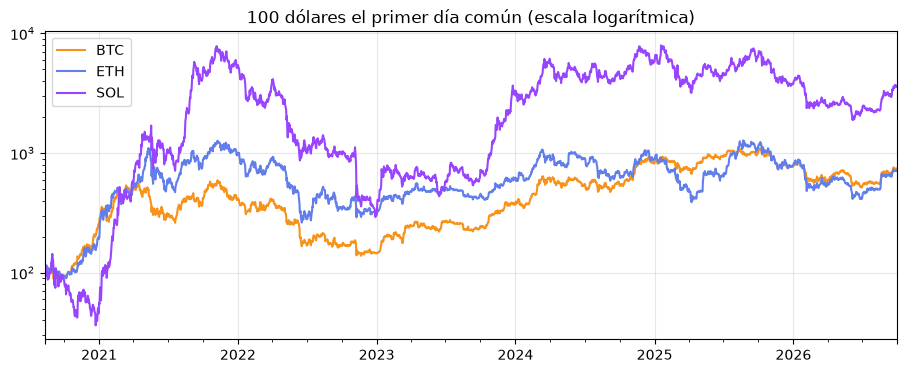

BTC     745.0
ETH     714.0
SOL    3590.0
Name: 2026-10-01 00:00:00+00:00, dtype: float64


In [8]:
comunes = cierres.dropna()                          # solo los días en que cotizan las tres
base100 = comunes / comunes.iloc[0] * 100
colores = {"BTC": "#F7931A", "ETH": "#627EEA", "SOL": "#9945FF"}
ax = base100.plot(logy=True, color=[colores[a] for a in base100], title="100 dólares el primer día común (escala logarítmica)")
ax.set_xlabel("")
plt.show()
print(base100.iloc[-1].round(0))

El eje vertical es **logarítmico**: la misma distancia vertical es el mismo porcentaje. Sin él, todo
lo anterior a la gran subida de SOL se vería plano.

## 6. Guardar la base

Descargar cada vez es lento y depende de que Binance responda. Por eso se guarda una copia en
**CSV**: texto plano que leen Python, R y Excel. Dos detalles:
- `index=False`, para no guardar el número de fila como una columna más.
- Fechas en formato ISO con zona (`2020-01-01T00:00:00Z`). Así R las lee sin ambigüedad.

Los archivos tienen el mismo nombre y formato que los CSV de respaldo del curso. Si un día Binance
no responde, puedes subir esos y todo funciona igual.

In [9]:
for a, df in base.items():
    df.to_csv(f"{a}USDT_1d.csv", index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
    print("guardado", f"{a}USDT_1d.csv", len(df), "filas")

guardado BTCUSDT_1d.csv 2466 filas


guardado ETHUSDT_1d.csv 2466 filas


guardado SOLUSDT_1d.csv 2243 filas


## 7. Caso aplicado: una base histórica que se mantiene sola

La función `velas` junta todo lo anterior: usa el CSV si ya existe y llega hasta la fecha pedida, y
si no, descarga de nuevo y lo guarda. Además fija el **periodo de estudio**: del 01-01-2020 al
26-09-2026. Fijarlo hace que todos veamos las mismas cifras, y que las de Python y las de R se
puedan comparar. Si quieres datos hasta ayer, pon `HASTA = None`.

Es exactamente la celda de *Preparación* con la que empiezan los demás cuadernos.

In [10]:
import os

DESDE, HASTA = "2020-01-01", "2026-09-26"


def velas(simbolo):
    """Velas diarias del periodo de estudio: del CSV si ya está, si no de Binance (y lo guarda)."""
    archivo = f"{simbolo}USDT_1d.csv"
    hoy = pd.Timestamp.now(tz="UTC").normalize()
    fin = pd.Timestamp(HASTA, tz="UTC") if HASTA else hoy - pd.Timedelta(days=1)
    df = None
    if os.path.exists(archivo):
        df = pd.read_csv(archivo)
        df["fecha"] = pd.to_datetime(df["fecha"], utc=True)
    if df is None or df["fecha"].max() < fin:        # no hay copia, o se ha quedado corta
        df = descargar(simbolo)
        df.to_csv(archivo, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
    df = df[(df["fecha"] >= pd.Timestamp(DESDE, tz="UTC")) & (df["fecha"] <= fin)]
    return df.set_index("fecha")


tabla = pd.DataFrame({a: velas(a)["close"] for a in ACTIVOS})
print(tabla.index.min().date(), "a", tabla.index.max().date(), "|", tabla.shape[0], "días")
tabla.tail(3)

2020-01-01 a 2026-09-26 | 2461 días


,BTC,ETH,SOL
fecha,,,
2026-09-24 00:00:00+00:00,84410.24,2688.05,117.04
2026-09-25 00:00:00+00:00,84099.99,2691.61,122.15
2026-09-26 00:00:00+00:00,84433.10,2696.33,121.41


## 8. Así lo hace el piloto

El módulo `cryptoquant/piloto/mercado.py` hace lo mismo que este cuaderno, con algunos cuidados más:

| En este cuaderno | En el piloto |
|---|---|
| `data-api.binance.vision`, velas diarias desde 2020 | lo mismo |
| quita la vela que no ha cerrado | lo mismo: decide con el último **cierre** diario |
| guarda un CSV por moneda | guarda las velas en `data/piloto/velas/` |
| si el CSV se queda corto, descarga todo de nuevo | descarga solo lo que falta y lo **junta** con lo guardado |
| — | si Binance no da velas hasta ayer, usa las que tiene y **avisa** en pantalla |

El aviso existe por un fallo real: una versión anterior, cuando la descarga fallaba, reemplazaba
las velas guardadas por otras más viejas y planificaba con datos de hacía un mes sin decirlo. La
lección vale para cualquier análisis: **un dato viejo que no avisa es peor que un error.**

En el botón **Actualizar precios** del piloto ocurre esta misma descarga.

## Ejercicios

1. **Velas horarias.** Cambia `"interval": "1d"` por `"1h"` en una petición y descarga las velas
   horarias de ETH de los últimos 7 días. ¿Cuántas filas deberían salir? ¿Salen?
2. **Una cuarta moneda.** Añade `"BNB"` a la tabla de cierres. ¿Desde qué fecha tiene datos?
   ¿Cuántos días comunes quedan con las cuatro?
3. **El error de las fechas.** Convierte `apertura_ms` con `unit="s"` en lugar de `unit="ms"`.
   ¿Qué error da, o qué fecha sale? ¿Y si tomas el campo 6 (cierre) como fecha?
4. **Volumen en dólares.** El campo 7 es el volumen en USDT. Añádelo a `descargar` y comprueba
   que se parece a `volume × close`. ¿Por qué no es exactamente igual?
5. **Para pensar.** El piloto pide a Binance solo datos públicos. ¿Qué información sobre ti
   recibe Binance cuando lo usas, y cuál no?